### CS/ECE/ISyE 524 &mdash; Introduction to Optimization &mdash; Spring 2026 ###

# GPU Task Scheduling Optimization #

#### Xuechun Jin (xjin252@wisc.edu), Jing Lan (jlan25@wisc.edu), Student 3 (email address)

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Implementation and Solution](#3.-Implementation)
1. [Discussion of Results](#4.-Results-discussion)
1. [Optional Subsection](#4.A.-Feel-free-to-add-subsections)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

Our project aims to improve GPU task scheduling by building optimization models. It includes a basic model and an extended model, both formulated as MILP models. We aim to improve the overall system performance by efficiently assigning tasks to limited GPU resources. Under different settings, we aim to minimize the total completion time when all tasks must be executed, and maximize the total task value within a limited time when tasks can be skipped. 

In our basic model, we have 20 tasks and 4 identical GPUs. Each task has two possible configurations, each specifying the number of GPUs required and the runtime to complete the task. For example, a task can take 24 minutes when using one GPU, but might only need 14 minutes when running on two. Each task can choose only one configuration, and all tasks must be executed. We present the execution order by assigning a start time and a finish time to each task, and we ensure that the total number of GPUs in use does not exceed 4 at any time. Our goal is to choose the best configuration combination and the order of executing tasks to minimize the total completion time. 

In the extended model, each task is assigned a value to represent its priority. A higher value means a higher priority. Unlike the basic model, tasks are not required to be executed, and some tasks can be skipped as needed. In addition, there is a total execution time budget now. Our goal is to select a subset of tasks and their execution order to maximize the total value of completed tasks within the time limit. 

Mordern GPUs are widely used in large-scale computing. However, once a GPU task starts running, it usually cannot be interrupted. When multiple applications share the same GPU, important tasks may be delayed for a long time. Therefore, It is important to schedule tasks properly so that high-value tasks can be completed as early as possible. This can improve the overall system performance and make better use of expensive GPU resoueces. An early work, TimeGraph [1], propoeses a GPU scheduling method that uses task priorities to decide the execution order, with a max running time constraint to prevent one task from abusing resources. However, for simplicity, we do not consider the execution time limits in our project. Another recent work introduces the operation of a shared GPU cluster on HKUST campus [2]. GPUs are offered in packs of 1, 2, 4, and 8. While this strategy mitigates the fragmentation issues, it losses some scheduling flexibility and assumes a decent cluster.

We do not use real data for this project. Instead, we generate synthetic data for GPU requirements, runtime, and task values. We also consider the following assumptions to simplify our models:
 - All GPUs are identical and can run tasks at the same time.
 - Tasks are independent from each other.
 - Tasks cannot be interrupted once it starts execution.
 - Each task can only choose one given configuration.
 - All tasks must be executed in the basic model.
 - Tasks can be skipped in the extended model. 

outline here! (write the entire report first then go back to write this part)

## 2. Mathematical model ##

## 2.A Basic Model ##

**Data:**
 - $p_{ik}$ is the running time for task $i$ with consiguration $k$
 - $g_{ik}$ is the required number of GPUs for task $i$ with consiguration $k$
 - $G$ is the total number of GPU
 - $N$ is the total number of tasks
 - $H$ is the upper bound of the total completion time: $H = \sum_{i = 1}^{N} \max_{k \in \{1, 2\}} p_{ik}$

**Decision variables:**

1. For the configuration selection and the task start time:
    $$
    x_{ikt} = \begin{cases}
    1, \quad\text{if task $i$ starts at time $t$ with configuration $k$} \\
    0, \quad\text{otherwise}
    \end{cases} \quad \forall i \in \{1, 2,..., N\}, k \in \{1, 2\}, t \in \{0, 1,..., H - p_{ik}\}
    $$

2. To evaluate the results, we define: $C$ as the total completion time (makespan) for all tasks. 

**Objective：**

Our objective is to minimize the makespan C:
    $$\min C$$

**Constraints:**

1. Each task has to choose exactly one configuration (means all tasks must be executed):
    $$\sum_{k \in \{1, 2\}}\sum_{t = 0}^{H - p_{ik}} x_{ikt} = 1 \quad \forall i \in \{1, 2,..., N\}$$
2. The total number of GPUs in use does not exceed 4 at any time point $r$.
    $$\sum_{i = 1}^{N} \sum_{k \in \{1, 2\}} \sum_{t \le r \le t + p_{ik} - 1} g_{ik}x_{ikt} \le G \quad \forall r \in \{0, 1,..., H\}$$
3. Makespan C must be greater than the completion time of every single tasks:
    $$C \ge \sum_{k \in \{1, 2\}} \sum_{t = 0}^{H - p_{ik}} (t + p_{ik})x_{ikt} \quad \forall i \in \{1, 2,..., N\}$$
4. Non-negativity:
    $$x_{ikt} \ge 0, \quad C \ge 0$$

**The full model in standard form:**
$$
\begin{aligned}
\max \quad& -C \\
\text{subject to} \quad
& \sum_{k \in \{1, 2\}}\sum_{t = 0}^{H - p_{ik}} x_{ikt} \le 1 \quad \forall i \in \{1, 2,..., N\}\\
& -\sum_{k \in \{1, 2\}}\sum_{t = 0}^{H - p_{ik}} x_{ikt} \le -1 \quad \forall i \in \{1, 2,..., N\}\\
& \sum_{i = 1}^{N} \sum_{k \in \{1, 2\}} \sum_{t \le r \le t + p_{ik} - 1} g_{ik}x_{ikt} \le G \quad \forall r \in \{0, 1,..., H\}\\
& \sum_{k \in \{1, 2\}} \sum_{t = 0}^{H - p_{ik}} (t + p_{ik})x_{ikt} \le C \quad \forall i \in \{1, 2,..., N\}\\
& x_{ikt} \ge 0, \quad C \ge 0\\
\end{aligned}
$$

## 2.B Extended Model ##

**Data:**
 - $p_{ik}$ is the running time for task $i$ with consiguration $k$
 - $g_{ik}$ is the required number of GPUs for task $i$ with consiguration $k$
 - $G$ is the total number of GPU
 - $N$ is the total number of tasks
 - $L$ is the given time limit
 - $v_i$ is the given task value for task $i$

**Decision variables:**

1. For the configuration selection and the task start time:
    $$
    x_{ikt} = \begin{cases}
    1, \quad\text{if task $i$ starts at time $t$ with configuration $k$} \\
    0, \quad\text{otherwise}
    \end{cases} \quad \forall i \in \{1, 2,..., N\}, k \in \{1, 2\}, t \in \{0, 1,..., L - p_{ik}\}
    $$


**Objective：**

Our objective is to maximize the total executed task value:
    $$\max \sum_{i = 1}^{N} \sum_{k \in \{1, 2\}}\sum_{t = 0}^{L - p_{ik}} v_ix_{ikt}$$

**Constraints:**

1. Each task can choose at most one configuration (tasks can be skipped):
    $$\sum_{k \in \{1, 2\}}\sum_{t = 0}^{L - p_{ik}} x_{ikt} \le 1 \quad \forall i \in \{1, 2,..., N\}$$
2. The total number of GPUs in use does not exceed 4 at any time point $r$:
    $$\sum_{i = 1}^{N} \sum_{k \in \{1, 2\}} \sum_{t \le r \le t + p_{ik} - 1} g_{ik}x_{ikt} \le G \quad \forall r \in \{0, 1,..., L\}$$
3. The completion time of all executed tasks cannot exceed L: Since we change the range of $t$ to $[0, L - p_{ik}]$, this requirement is met automatically.
4. Non-negativity:
    $$x_{ikt} \ge 0$$

**The full model in standard form:**
$$
\begin{aligned}
\max \quad& \sum_{i = 1}^{N} \sum_{k \in \{1, 2\}}\sum_{t = 0}^{L - p_{ik}} v_ix_{ikt} \\
\text{subject to} \quad
& \sum_{k \in \{1, 2\}}\sum_{t = 0}^{L - p_{ik}} x_{ikt} \le 1 \quad \forall i \in \{1, 2,..., N\}\\\
& \sum_{i = 1}^{N} \sum_{k \in \{1, 2\}} \sum_{t \le r \le t + p_{ik} - 1} g_{ik}x_{ikt} \le G \quad \forall r \in \{0, 1,..., L\}\\
& x_{ikt} \ge 0\\
\end{aligned}
$$

## 3. Implementation \& Solutions ##

## 3.A Data Generation ##

In [2]:
using JuMP, HiGHS, Random
# data generated are the same everytime
Random.seed!(1218)

# the number of GPUs
G = 4
# the number of tasks
N = 20
# p is the running time. Configurations with more GPUs run faster
# so config 1 needs 1 GPU, runtime is between 10 to 30 minutes
# config 2 needs 2 GPUs, runtime is between 5 to 5 minutes less than the runtime of config 1
p = zeros(Int, N, 2)
for i in 1:N
    p[i, 1] = rand(15:30)
    p[i, 2] = rand(5:p[i, 1]-5)
end
# g: required number of GPUs for config 1 and 2
g = ones(Int, N, 2)
g[:, 2] .= 2
# H: the upperbound
H = sum(maximum(p[i, :]) for i in 1:N)

451

In [2]:
# print out the data
println(p)
println(g)

[24 14; 15 5; 27 6; 21 6; 23 16; 15 9; 25 9; 26 11; 18 12; 18 13; 27 9; 19 5; 26 17; 23 15; 26 11; 18 7; 25 9; 25 17; 30 23; 20 9]
[1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2; 1 2]


To make the data more clear, we present it as the following table. Config 1 requires 1 GPU and Config 2 requires 2 GPUs. 

| Task | Config 1 Runtime (mins) | Config 2 Runtime (mins) |
|-----:|------------------------:|------------------------:|
| 1    | 24                      | 14                      |
| 2    | 15                      | 5                       |
| 3    | 27                      | 6                       |
| 4    | 21                      | 6                       |
| 5    | 23                      | 16                      |
| 6    | 15                      | 9                       |
| 7    | 25                      | 9                       |
| 8    | 26                      | 11                      |
| 9    | 18                      | 12                      |
| 10   | 18                      | 13                      |
| 11   | 27                      | 9                       |
| 12   | 19                      | 5                       |
| 13   | 26                      | 17                      |
| 14   | 23                      | 15                      |
| 15   | 26                      | 11                      |
| 16   | 18                      | 7                       |
| 17   | 25                      | 9                       |
| 18   | 25                      | 17                      |
| 19   | 30                      | 23                      |
| 20   | 20                      | 9                       |

## 3.B Code for the Basic Model ##

In [3]:
m = Model(HiGHS.Optimizer)

# define x_ikt as a binary variable
@variable(m, x[i = 1:N, k = 1:2, t = 0:H - p[i,k]], Bin)  
@variable(m, C >= 0)  

@objective(m, Min, C) 
   
# each task has to choose exactly one configuration
@constraint(m, config[i in 1:N], sum(x[i, k, t] for k in 1:2, t in 0:H - p[i,k]) == 1)  
# the total number of GPUs in use does not exceed 4 at anytime
# t cannot be less than 0
@constraint(m, gpu[r in 0:H], sum(g[i, k]*x[i, k, t] 
        for i in 1:N, k in 1:2, t in max(0, r - p[i, k] + 1):min(r, H - p[i,k])) <= G)  
# makespan C must be greater than the completion time of every single tasks
@constraint(m, makespan[i in 1:N], sum((t + p[i, k])*x[i, k, t] for k in 1:2, t in 0:H - p[i,k]) <= C)  

# run optimizer
set_silent(m)
optimize!(m)


# print the results
println("The optimal result (Min makespan): ", objective_value(m), " mins.") 
for i in 1:N
    for k in 1:2
        for t in 0:H-p[i,k]
            # only print out the configs that are selected
            # we use > 0.9 instead of == 1 because sometimes the solver returns 0.999999
            if value(x[i, k, t]) > 0.9
                println("Task $i uses config $k, start time is $t, finish time = $(t + p[i, k])")
            end
        end
    end
end


The optimal result (Min makespan): 94.0 mins.
Task 1 uses config 1, start time is 19, finish time = 43
Task 2 uses config 2, start time is 5, finish time = 10
Task 3 uses config 2, start time is 9, finish time = 15
Task 4 uses config 2, start time is 24, finish time = 30
Task 5 uses config 1, start time is 19, finish time = 42
Task 6 uses config 1, start time is 61, finish time = 76
Task 7 uses config 2, start time is 37, finish time = 46
Task 8 uses config 2, start time is 83, finish time = 94
Task 9 uses config 1, start time is 76, finish time = 94
Task 10 uses config 1, start time is 43, finish time = 61
Task 11 uses config 2, start time is 10, finish time = 19
Task 12 uses config 2, start time is 0, finish time = 5
Task 13 uses config 1, start time is 46, finish time = 72
Task 14 uses config 1, start time is 46, finish time = 69
Task 15 uses config 2, start time is 72, finish time = 83
Task 16 uses config 2, start time is 30, finish time = 37
Task 17 uses config 2, start time is 15

## 3.C Code for the Extended Model ##

In [3]:
# add two more types of data
# time limit L
# since the min makespan is 94 mins, then we need to choose a number that is smaller than 94
L = 70
# task values, randomly generated from 1 to 10 for each task
# tasks have higher value have high priority

# v = rand(1:10, N);
v = [10, 9, 1, 1, 1, 9, 5, 2, 6, 1, 10, 5, 6, 3, 5, 5, 5, 8, 3, 1];

In [5]:
# print out task values
println(v)

[10, 9, 1, 1, 1, 9, 5, 2, 6, 1, 10, 5, 6, 3, 5, 5, 5, 8, 3, 1]


The data for the extended model is as shown below:
| Task | Config 1 Runtime (mins) | Config 2 Runtime (mins) | Value |
|-----:|------------------------:|------------------------:|------:|
| 1    | 24                      | 14                      | 10    |
| 2    | 15                      | 5                       | 9     |
| 3    | 27                      | 6                       | 1     |
| 4    | 21                      | 6                       | 1     |
| 5    | 23                      | 16                      | 1     |
| 6    | 15                      | 9                       | 9     |
| 7    | 25                      | 9                       | 5     |
| 8    | 26                      | 11                      | 2     |
| 9    | 18                      | 12                      | 6     |
| 10   | 18                      | 13                      | 1     |
| 11   | 27                      | 9                       | 10    |
| 12   | 19                      | 5                       | 5     |
| 13   | 26                      | 17                      | 6     |
| 14   | 23                      | 15                      | 3     |
| 15   | 26                      | 11                      | 5     |
| 16   | 18                      | 7                       | 5     |
| 17   | 25                      | 9                       | 5     |
| 18   | 25                      | 17                      | 8     |
| 19   | 30                      | 23                      | 3     |
| 20   | 20                      | 9                       | 1     |

In [6]:
m_extended = Model(HiGHS.Optimizer)

# define x_ikt as a binary variable
@variable(m_extended, x[i = 1:N, k = 1:2, t = 0:L - p[i,k]], Bin)  

@objective(m_extended, Max, sum(v[i]*x[i, k, t] for i in 1:N, k in 1:2, t in 0:L - p[i,k]))
   
# each task has to choose at most one configuration
@constraint(m_extended, config[i in 1:N], sum(x[i, k, t] for k in 1:2, t in 0:L - p[i,k]) <= 1)  
# the total number of GPUs in use does not exceed 4 at anytime
# t cannot be less than 0
@constraint(m_extended, gpu[r in 0:L], sum(g[i, k]*x[i, k, t] 
        for i in 1:N, k in 1:2, t in max(0, r - p[i, k] + 1):min(r, L - p[i,k])) <= G)  
    
# run optimizer
set_silent(m_extended)
optimize!(m_extended)

executed = false
# print the results
println("The optimal result (Max value): ", objective_value(m_extended)) 
for i in 1:N
    executed = false
    for k in 1:2
        for t in 0:L-p[i,k]
            # only print out the executed tasks and configs
            # we use > 0.9 instead of == 1 because sometimes the solver returns 0.999999
            if value(x[i, k, t]) > 0.9
                println("Task $i uses config $k, start time is $t, finish time = $(t + p[i, k]), has value $(v[i])")
                executed = true
            end
        end
    end
    # print out skipped tasks
    if executed == false
        println("Task $i is skipped with value $(v[i])")
    end
end


The optimal result (Max value): 89.0
Task 1 uses config 1, start time is 20, finish time = 44, has value 10
Task 2 uses config 2, start time is 65, finish time = 70, has value 9
Task 3 is skipped with value 1
Task 4 uses config 2, start time is 46, finish time = 52, has value 1
Task 5 is skipped with value 1
Task 6 uses config 1, start time is 45, finish time = 60, has value 9
Task 7 uses config 2, start time is 61, finish time = 70, has value 5
Task 8 uses config 2, start time is 26, finish time = 37, has value 2
Task 9 uses config 1, start time is 20, finish time = 38, has value 6
Task 10 is skipped with value 1
Task 11 uses config 2, start time is 52, finish time = 61, has value 10
Task 12 uses config 2, start time is 60, finish time = 65, has value 5
Task 13 uses config 1, start time is 0, finish time = 26, has value 6
Task 14 uses config 1, start time is 37, finish time = 60, has value 3
Task 15 uses config 2, start time is 9, finish time = 20, has value 5
Task 16 uses config 2, s

## 3.D Effect of total GPU capacity on the optimal makespan ##

In this section, we explore the relationship between the total GPU availability and the optimal makespan from our basic model. Instead of a fixed capacity of 4 GPUs, we solve the same basic model with different GPU capacity parameters. 

We observe that the optimal makespan monotonously decreases as the number of available GPUs increases. Since any task can run with only 1 GPU (config 1), the optimal makespan equals the upperbonund execution time $H$ when only 1 device is offered. The optimal makespan when $G_{val} = 4$ is consistent with the result we obtained from section 3.B.

Solving for total GPU capacity: 1...
Total GPU Capacity: 1, Optimal Makespan: 451.0 mins.
Solving for total GPU capacity: 2...
Total GPU Capacity: 2, Optimal Makespan: 247.0 mins.
Solving for total GPU capacity: 3...
Total GPU Capacity: 3, Optimal Makespan: 130.0 mins.
Solving for total GPU capacity: 4...
Total GPU Capacity: 4, Optimal Makespan: 94.0 mins.
Solving for total GPU capacity: 5...
Total GPU Capacity: 5, Optimal Makespan: 77.0 mins.
Solving for total GPU capacity: 6...
Total GPU Capacity: 6, Optimal Makespan: 63.0 mins.
Solving for total GPU capacity: 7...
Total GPU Capacity: 7, Optimal Makespan: 54.0 mins.
Solving for total GPU capacity: 8...
Total GPU Capacity: 8, Optimal Makespan: 47.0 mins.


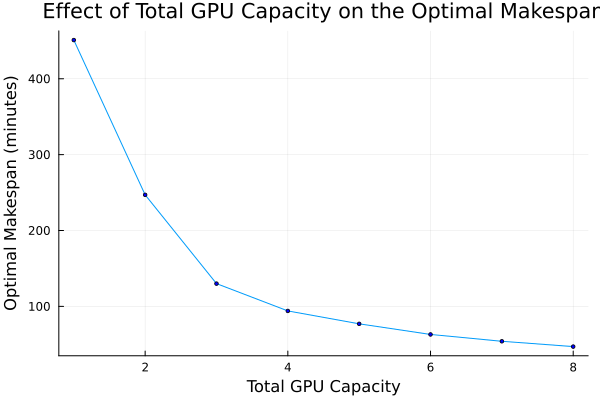

In [7]:
function solveBasic(G_val)
    # the same basic model from above
    m = Model(HiGHS.Optimizer)
    @variable(m, x[i = 1:N, k = 1:2, t = 0:H - p[i,k]], Bin)  
    @variable(m, C >= 0)  
    
    @objective(m, Min, C) 
       
    # each task has to choose exactly one configuration
    @constraint(m, config[i in 1:N], sum(x[i, k, t] for k in 1:2, t in 0:H - p[i,k]) == 1)  
    # the total number of GPUs in use does not exceed G_val at any time
    # t cannot be less than 0
    @constraint(m, gpu[r in 0:H], sum(g[i, k]*x[i, k, t] 
            for i in 1:N, k in 1:2, t in max(0, r - p[i, k] + 1):min(r, H - p[i,k])) <= G_val)  
    # makespan C must be greater than the completion time of every single tasks
    @constraint(m, makespan[i in 1:N], sum((t + p[i, k])*x[i, k, t] for k in 1:2, t in 0:H - p[i,k]) <= C)  
    
    set_silent(m)
    set_time_limit_sec(m, 120.0)
    optimize!(m)

    return objective_value(m)
end

# we consider GPU numbers from 1 to 8
G_numbers = 1:8
makespan = zeros(8)

# find the corresponding optimal makespan
for (i, G_val) in enumerate(G_numbers)
    println("Solving for total GPU capacity: $G_val...")
    makespan[i] = solveBasic(G_val)
    println("Total GPU Capacity: $G_val, Optimal Makespan: $(makespan[i]) mins.")
end

# plot the relationship between total GPU capacity and optimal makespan
using Plots
plot(G_numbers, makespan, mc=:blue, markershape=:circle, legend=false, markersize=2 )
xlabel!("Total GPU Capacity")
ylabel!("Optimal Makespan (minutes)");
display(title!("Effect of Total GPU Capacity on the Optimal Makespan"))


## 3.E Tradeoff between the time limit and task value ##

In this experiment, the total GPU capacity remains fixed, while the time limit varies. For each value of the time limit, we solve the extended model to maximize the total task value obtained within that time budget. This allows us to examine the tradeoff between a tighter scheduling horizon and the amount of value that can be obtained.

In [ ]:
function solveExtended(L_val)
    # the extended model with a variable time limit L_val
    m_extended = Model(HiGHS.Optimizer)

    # tasks with runtime longer than L_val have no feasible start time
    @variable(m_extended, x[i = 1:N, k = 1:2, t = 0:L_val - p[i,k]], Bin)  
    @objective(m_extended, Max, sum(v[i]*x[i, k, t] for i in 1:N, k in 1:2, t in 0:L_val - p[i,k]))
       
    # each task has to choose at most one configuration
    @constraint(m_extended, config[i in 1:N], sum(x[i, k, t] for k in 1:2, t in 0:L_val - p[i,k]) <= 1)  
    # the total number of GPUs in use does not exceed G at any time
    # t cannot be less than 0
    @constraint(m_extended, gpu[r in 0:L_val], sum(g[i, k]*x[i, k, t] 
            for i in 1:N, k in 1:2, t in max(0, r - p[i, k] + 1):min(r, L_val - p[i,k])) <= G)  
        
    set_silent(m_extended)
    optimize!(m_extended)
    return objective_value(m_extended)
end

# from 40 to 100, choose every 5 minutes
L_numbers = 40:5:100
values = zeros(length(L_numbers))

# find the corresponding optimal total task value
for (i, L_val) in enumerate(L_numbers)
    values[i] = solveExtended(L_val)
end

# plot the tradeoff between time limit and total task value
plot(L_numbers, values, mc=:blue, markershape=:circle, legend=false, markersize=2 )
xlabel!("Time Limit (minutes)")
ylabel!("Optimal Total Task Value");
display(title!("Tradeoff between Time Limit and Total Task Value"))


## 3.F Long-tail task experiment in the extended model ##

In this section, We want to test how the extended model responds to a long-tail task with a much longer runtime. We fix the time limit at 70 minutes and modify Task 1 so that it takes 50 minutes with Config 1 and 25 minutes with Config 2, while keeping its task value at 10. We then solve the extended model to see whether the optimizer still chooses to execute Task 1 or decides to skip it in favor of shorter tasks.

In [5]:
using JuMP, HiGHS, Random

function solveExtended(p_data, v_data, L_val)
    m_extended = Model(HiGHS.Optimizer)

    @variable(m_extended, x[i = 1:N, k = 1:2, t = 0:L_val - p_data[i,k]], Bin)
    @objective(m_extended, Max, sum(v_data[i] * x[i, k, t] for i in 1:N, k in 1:2, t in 0:L_val - p_data[i,k]))

    @constraint(m_extended, config[i in 1:N], sum(x[i, k, t] for k in 1:2, t in 0:L_val - p_data[i,k]) <= 1)
    @constraint(m_extended, gpu[r in 0:L_val], sum(g[i, k] * x[i, k, t]
            for i in 1:N, k in 1:2, t in max(0, r - p_data[i, k] + 1):min(r, L_val - p_data[i,k])) <= G)

    set_silent(m_extended)
    set_time_limit_sec(m_extended, 60.0)
    optimize!(m_extended)

    selected = falses(N)
    chosen_config = zeros(Int, N)
    start_time = fill(-1, N)

    for i in 1:N, k in 1:2, t in 0:L_val - p_data[i,k]
        if value(x[i, k, t]) > 0.9
            selected[i] = true
            chosen_config[i] = k
            start_time[i] = t
        end
    end

    return termination_status(m_extended), objective_value(m_extended), selected, chosen_config, start_time
end

L_fixed = 70
p_longtail = copy(p)
p_longtail[1, 1] = 50
p_longtail[1, 2] = 25

for v1 in 1:10
    v_longtail = copy(v)
    v_longtail[1] = v1

    status, obj, selected, chosen_config, start_time = solveExtended(p_longtail, v_longtail, L_fixed)

    if selected[1]
        println("Task 1 value = $v1: SELECTED (Config $(chosen_config[1]), start = $(start_time[1]) min) | Total value = $obj")
    else
        println("Task 1 value = $v1: SKIPPED | Total value = $obj")
    end
end


Task 1 value = 1: SKIPPED | Total value = 81.0
Task 1 value = 2: SKIPPED | Total value = 81.0
Task 1 value = 3: SKIPPED | Total value = 81.0
Task 1 value = 4: SKIPPED | Total value = 81.00000000000762
Task 1 value = 5: SELECTED (Config 1, start = 6 min) | Total value = 81.00000000002902
Task 1 value = 6: SELECTED (Config 1, start = 20 min) | Total value = 82.00000000001542
Task 1 value = 7: SELECTED (Config 2, start = 23 min) | Total value = 83.00000000001974
Task 1 value = 8: SELECTED (Config 1, start = 11 min) | Total value = 84.00000000007272
Task 1 value = 9: SELECTED (Config 2, start = 7 min) | Total value = 85.00000000005782
Task 1 value = 10: SELECTED (Config 1, start = 20 min) | Total value = 86.00000000002339
HighsMipSolverData::transformNewIntegerFeasibleSolution tmpSolver.run();
HighsMipSolverData::transformNewIntegerFeasibleSolution tmpSolver.run();
HighsMipSolverData::transformNewIntegerFeasibleSolution tmpSolver.run();
HighsMipSolverData::transformNewIntegerFeasibleSoluti

## 4. Discussion of Results ##

Here, you display and discuss the results. Show figures, tables, plots, images, trade-off curves, or whatever else you can think of to best illustrate your results. The discussion should explain what the results mean, and how to interpret them. You should also explain the limitations of your approach/model and how sensitive your results are to the assumptions you made.

 Use plots (see `Plots` examples from class), or you can display results in a table like this:

| Tables        | Are          | Cool  |
| ------------- |:-------------| -----:|
| col 3 is      |right-aligned |\$1600 |
|  colons       | align columns|  \$12 |
| zebra stripes |    are neat  |   \$1 |

### 4.A. Feel free to add subsections

#### 4.A.a. or subsubsections

## 5. Conclusion ##

Summarize your findings and your results, and talk about at least one possible future direction; something that might be interesting to pursue as a follow-up to your project.

## 6. Reference ##

1. Kato, Shinpei, et al. "{TimeGraph}:{GPU} Scheduling for {Real-Time}{Multi-Tasking} Environments." 2011 USENIX Annual Technical Conference (USENIX ATC 11). 2011.
2. Xu, Kaiqiang, et al. "Design and operation of shared machine learning clusters on campus." Proceedings of the 30th ACM International Conference on Architectural Support for Programming Languages and Operating Systems, Volume 1. 2025.
